# Import Library & CSV

In [1]:
import pandas as pd
dataset= pd.read_csv("Building_Energy_Efficiency.csv")
dataset

,Building_ID,Relative_Compactness,Building_Type,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Orientation,Glazing_Area_ratio,Glazing_Distribution,Heating_Load_kWh,Cooling_Load_kWh
0,BLD-0001,0.98,High_Rise,514.5,294.0,110.25,7.0,North,0.0,NaN,15.55,21.33
1,BLD-0002,0.98,High_Rise,514.5,294.0,110.25,7.0,East,0.0,NaN,15.55,21.33
2,BLD-0003,0.98,High_Rise,514.5,294.0,110.25,7.0,South,0.0,NaN,15.55,21.33
3,BLD-0004,0.98,High_Rise,514.5,NaN,110.25,7.0,West,0.0,NaN,NaN,21.33
4,BLD-0005,0.90,High_Rise,563.5,318.5,122.50,7.0,NaN,0.0,NaN,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...,...,...
763,BLD-0764,0.64,Low_Rise,784.0,343.0,220.50,3.5,West,0.4,West_Heavy,17.88,21.40
764,BLD-0765,0.62,Low_Rise,808.5,367.5,220.50,3.5,North,0.4,NaN,16.54,16.88
765,BLD-0766,0.62,Low_Rise,808.5,367.5,220.50,3.5,East,0.4,West_Heavy,16.44,17.11
766,BLD-0767,0.62,Low_Rise,808.5,367.5,220.50,3.5,South,0.4,West_Heavy,16.48,16.61


# Check No. of columns& Rows

In [2]:
# Check shape (rows, columns)
dataset.shape
print(dataset.shape)

(768, 12)


In [3]:
# Column names
dataset.columns
print(dataset.columns)

Index(['Building_ID', 'Relative_Compactness', 'Building_Type',
       'Surface_Area_m2', 'Wall_Area_m2', 'Roof_Area_m2', 'Overall_Height_m',
       'Orientation', 'Glazing_Area_ratio', 'Glazing_Distribution',
       'Heating_Load_kWh', 'Cooling_Load_kWh'],
      dtype='object')


In [4]:
# Data types
dataset.dtypes
print(dataset.dtypes)

Building_ID              object
Relative_Compactness    float64
Building_Type            object
Surface_Area_m2         float64
Wall_Area_m2            float64
Roof_Area_m2            float64
Overall_Height_m        float64
Orientation              object
Glazing_Area_ratio      float64
Glazing_Distribution     object
Heating_Load_kWh        float64
Cooling_Load_kWh        float64
dtype: object


# Check Missing Values

In [5]:
dataset.isnull().sum()

Building_ID               0
Relative_Compactness     38
Building_Type             0
Surface_Area_m2          30
Wall_Area_m2             46
Roof_Area_m2             38
Overall_Height_m         23
Orientation              53
Glazing_Area_ratio       61
Glazing_Distribution    112
Heating_Load_kWh         30
Cooling_Load_kWh         30
dtype: int64

# Split Qualitative and Quantitative columns

In [6]:
def quanQual(dataset):
        quan=[]
        qual=[]
        for columnName in dataset.columns:
            #print(columnName)
            if(dataset[columnName].dtype=='O'):
                #print("qual")
                qual.append(columnName)
            else:
                #print("quan")
                quan.append(columnName)
        return quan,qual

In [7]:
quan,qual=quanQual(dataset)

In [8]:
dataset[quan]

,Relative_Compactness,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Glazing_Area_ratio,Heating_Load_kWh,Cooling_Load_kWh
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
3,0.98,514.5,NaN,110.25,7.0,0.0,NaN,21.33
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28
...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,0.4,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,0.4,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,0.4,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,0.4,16.48,16.61


In [9]:
dataset[qual]

,Building_ID,Building_Type,Orientation,Glazing_Distribution
0,BLD-0001,High_Rise,North,NaN
1,BLD-0002,High_Rise,East,NaN
2,BLD-0003,High_Rise,South,NaN
3,BLD-0004,High_Rise,West,NaN
4,BLD-0005,High_Rise,NaN,NaN
...,...,...,...,...
763,BLD-0764,Low_Rise,West,West_Heavy
764,BLD-0765,Low_Rise,North,NaN
765,BLD-0766,Low_Rise,East,West_Heavy
766,BLD-0767,Low_Rise,South,West_Heavy


# Fill missing values with median (numerical columns)

In [10]:
import numpy as np
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan,strategy="median")
dataset[quan] = imputer.fit_transform(dataset[quan])

In [11]:
dataset[quan]

,Relative_Compactness,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Glazing_Area_ratio,Heating_Load_kWh,Cooling_Load_kWh
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33
3,0.98,514.5,318.5,110.25,7.0,0.0,19.27,21.33
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28
...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,0.4,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,0.4,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,0.4,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,0.4,16.48,16.61


In [12]:
# Fill missing values with median (numerical columns)
dataset[quan].isnull().sum()

Relative_Compactness    0
Surface_Area_m2         0
Wall_Area_m2            0
Roof_Area_m2            0
Overall_Height_m        0
Glazing_Area_ratio      0
Heating_Load_kWh        0
Cooling_Load_kWh        0
dtype: int64

In [13]:
#no null values

# Fill missing values with median (categorical columns)

In [14]:
# Fill nominal columns with mode
dataset['Building_Type'] = dataset['Building_Type'].fillna(
    dataset['Building_Type'].mode()[0]
)

dataset['Orientation'] = dataset['Orientation'].fillna(
    dataset['Orientation'].mode()[0]
)

In [15]:
#Ordinal Column with mode
dataset['Glazing_Distribution'] = dataset['Glazing_Distribution'].fillna(
    dataset['Glazing_Distribution'].mode()[0]
)

In [16]:
dataset[qual]

,Building_ID,Building_Type,Orientation,Glazing_Distribution
0,BLD-0001,High_Rise,North,East_Heavy
1,BLD-0002,High_Rise,East,East_Heavy
2,BLD-0003,High_Rise,South,East_Heavy
3,BLD-0004,High_Rise,West,East_Heavy
4,BLD-0005,High_Rise,West,East_Heavy
...,...,...,...,...
763,BLD-0764,Low_Rise,West,West_Heavy
764,BLD-0765,Low_Rise,North,East_Heavy
765,BLD-0766,Low_Rise,East,West_Heavy
766,BLD-0767,Low_Rise,South,West_Heavy


In [17]:
dataset[qual].isnull().sum()

Building_ID             0
Building_Type           0
Orientation             0
Glazing_Distribution    0
dtype: int64

In [18]:
#no null values

In [19]:
dataset

,Building_ID,Relative_Compactness,Building_Type,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Orientation,Glazing_Area_ratio,Glazing_Distribution,Heating_Load_kWh,Cooling_Load_kWh
0,BLD-0001,0.98,High_Rise,514.5,294.0,110.25,7.0,North,0.0,East_Heavy,15.55,21.33
1,BLD-0002,0.98,High_Rise,514.5,294.0,110.25,7.0,East,0.0,East_Heavy,15.55,21.33
2,BLD-0003,0.98,High_Rise,514.5,294.0,110.25,7.0,South,0.0,East_Heavy,15.55,21.33
3,BLD-0004,0.98,High_Rise,514.5,318.5,110.25,7.0,West,0.0,East_Heavy,19.27,21.33
4,BLD-0005,0.90,High_Rise,563.5,318.5,122.50,7.0,West,0.0,East_Heavy,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...,...,...
763,BLD-0764,0.64,Low_Rise,784.0,343.0,220.50,3.5,West,0.4,West_Heavy,17.88,21.40
764,BLD-0765,0.62,Low_Rise,808.5,367.5,220.50,3.5,North,0.4,East_Heavy,16.54,16.88
765,BLD-0766,0.62,Low_Rise,808.5,367.5,220.50,3.5,East,0.4,West_Heavy,16.44,17.11
766,BLD-0767,0.62,Low_Rise,808.5,367.5,220.50,3.5,South,0.4,West_Heavy,16.48,16.61


In [20]:
dataset.isnull().sum()

Building_ID             0
Relative_Compactness    0
Building_Type           0
Surface_Area_m2         0
Wall_Area_m2            0
Roof_Area_m2            0
Overall_Height_m        0
Orientation             0
Glazing_Area_ratio      0
Glazing_Distribution    0
Heating_Load_kWh        0
Cooling_Load_kWh        0
dtype: int64

In [21]:
#no overall null values

In [22]:
dataset.to_csv("Preprocessed_BuildingEnergy.csv",index=False)

# Central Tendency

In [23]:
dataset.describe()

,Relative_Compactness,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Glazing_Area_ratio,Heating_Load_kWh,Cooling_Load_kWh
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.762539,672.027344,318.946615,179.204102,5.190755,0.237305,22.323940,24.485039
std,0.102896,86.173123,42.864113,44.932670,1.750137,0.126886,9.935993,9.313741
min,0.620000,514.500000,245.000000,110.250000,3.500000,0.000000,6.010000,10.900000
25%,0.690000,612.500000,294.000000,147.000000,3.500000,0.100000,13.140000,15.795000
50%,0.740000,673.750000,318.500000,220.500000,3.500000,0.250000,19.270000,22.170000
75%,0.820000,735.000000,343.000000,220.500000,7.000000,0.400000,31.632500,32.890000
max,0.980000,808.500000,416.500000,220.500000,7.000000,0.400000,43.100000,48.030000


# Frequency

In [24]:
def freqTable(columnName,dataset):
    freqTable=pd.DataFrame(columns=["Unique_Values","Frequency","Relative_Frequency","CumSum"])
    freqTable["Unique_Values"]=dataset[columnName].value_counts().index
    freqTable["Frequency"]=dataset[columnName].value_counts().values
    freqTable["Relative_Frequency"]=freqTable["Frequency"] / freqTable["Frequency"].sum()
    freqTable["CumSum"]=freqTable["Relative_Frequency"].cumsum()
    return freqTable

In [25]:
freqTable("Surface_Area_m2",dataset)

,Unique_Values,Frequency,Relative_Frequency,CumSum
0,759.50,63,0.082031,0.082031
1,588.00,63,0.082031,0.164062
2,735.00,62,0.080729,0.244792
3,686.00,62,0.080729,0.325521
4,637.00,62,0.080729,0.406250
5,612.50,62,0.080729,0.486979
6,784.00,62,0.080729,0.567708
7,563.50,61,0.079427,0.647135
8,808.50,61,0.079427,0.726563
9,661.50,61,0.079427,0.805990


# Univeriate Analysis

In [26]:
def Univariate(dataset,Quan):
    descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","99%","Q4:100%","IQR",
                                    "1.5rule","Lesser","Greater","Min","Max","kurtosis","skew","Variance",
                                    "StandardD"],columns=Quan)
    for columnName in Quan:
        descriptive[columnName]["Mean"]=dataset[columnName].mean()
        descriptive[columnName]["Median"]=dataset[columnName].median()
        descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
        descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
        descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
        descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
        descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
        descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
        descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
        descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Max"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["kurtosis"]=dataset[columnName].kurtosis()
        descriptive[columnName]["skew"]=dataset[columnName].skew()
        descriptive[columnName]["Variance"]=dataset[columnName].var()
        descriptive[columnName]["StandardD"]=dataset[columnName].std()
    return descriptive

In [27]:
Univariate(dataset,quan)

,Relative_Compactness,Surface_Area_m2,Wall_Area_m2,Roof_Area_m2,Overall_Height_m,Glazing_Area_ratio,Heating_Load_kWh,Cooling_Load_kWh
Mean,0.762539,672.027,318.947,179.204,5.19076,0.237305,22.3239,24.485
Median,0.74,673.75,318.5,220.5,3.5,0.25,19.27,22.17
Mode,0.74,588,318.5,220.5,3.5,0.25,19.27,22.17
Q1:25%,0.69,612.5,294,147,3.5,0.1,13.14,15.795
Q2:50%,0.74,673.75,318.5,220.5,3.5,0.25,19.27,22.17
Q3:75%,0.82,735,343,220.5,7,0.4,31.6325,32.89
99%,0.98,808.5,416.5,220.5,7,0.4,42.0899,45.5431
Q4:100%,0.98,808.5,416.5,220.5,7,0.4,43.1,48.03
IQR,0.13,122.5,49,73.5,3.5,0.3,18.4925,17.095
1.5rule,0.195,183.75,73.5,110.25,5.25,0.45,27.7387,25.6425


# Numerical Features Analysis

# Relative Compactness
1. Do most buildings in this dataset have a similar shape, or does it vary widely?
2. Are there any unusually "boxy" or unusually "spread out" buildings that are outliers?

In [28]:
# Basic statistics
print("Min:", dataset['Relative_Compactness'].min())
print("Max:", dataset['Relative_Compactness'].max())
print("Mean:", dataset['Relative_Compactness'].mean())
print("Std Dev:", dataset['Relative_Compactness'].std())

Min: 0.62
Max: 0.98
Mean: 0.7625390625
Std Dev: 0.10289644183359471


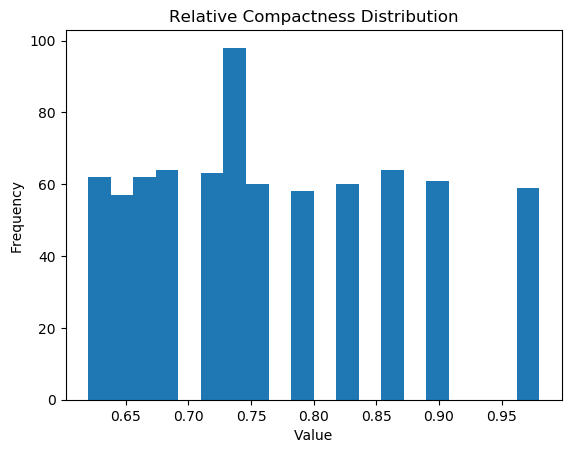

In [29]:
import matplotlib.pyplot as plt

plt.hist(dataset['Relative_Compactness'], bins=20)
plt.title("Relative Compactness Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Lower value → more spread out
Higher value → more boxy/compact

ie Many buildings fall in one range - So designs are not very diverse
   Some buildings go up to 0.9+ - These are more compact (boxy) buildings
   

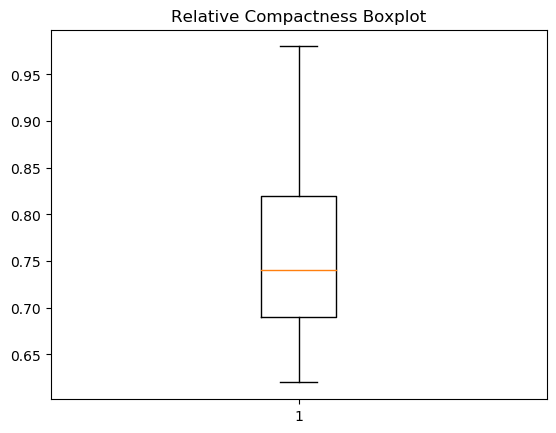

In [30]:
# Boxplot
plt.boxplot(dataset['Relative_Compactness'])
plt.title("Relative Compactness Boxplot")
plt.show()

There are no dots outside the whiskers - ( no outliers)
The box (middle part) is roughly 0.69 → 0.82 -( Most buildings have similar compactness)

# Surface Area
3. What is the most common building footprint size in this dataset? 
4. Are large-surface buildings rare exceptions or fairly common?

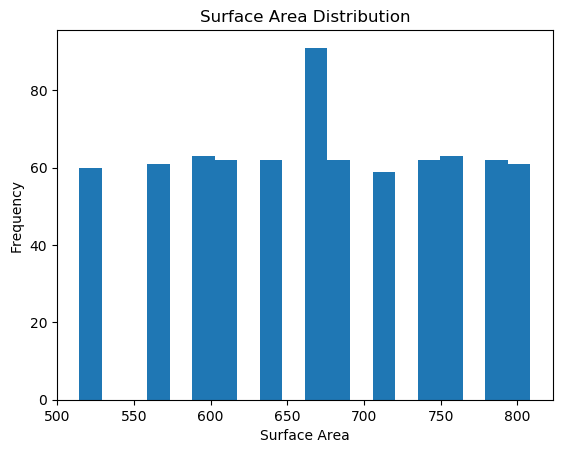

In [31]:
import matplotlib.pyplot as plt

# Histogram
plt.hist(dataset['Surface_Area_m2'], bins=20)
plt.title("Surface Area Distribution")
plt.xlabel("Surface Area")
plt.ylabel("Frequency")
plt.show()

In [32]:
# Most buildings have surface area around 650–700
# The surface area is fairly evenly distributed across the dataset ie large areas (700-800)are common

# Overall Height 
5. Are buildings in this dataset mostly low-rise or high-rise, or a mix of both? 

In [33]:
# Check unique values
dataset['Overall_Height_m'].unique()

array([7. , 3.5])

In [34]:
# Count how many of each height
dataset['Overall_Height_m'].value_counts()

3.5    397
7.0    371
Name: Overall_Height_m, dtype: int64

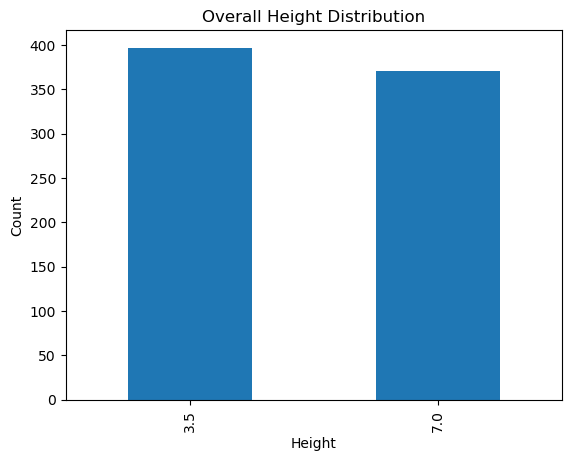

In [35]:
import matplotlib.pyplot as plt

dataset['Overall_Height_m'].value_counts().plot(kind='bar')
plt.title("Overall Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

In [36]:
#It’s a mix of both, fairly balanced

# Glazing Area Ratio 
6. What proportion of buildings have no glazing at all? And how many are heavily glazed? 
7. Is glazing evenly distributed or do buildings cluster at a few common glazing levels?

In [37]:
# Unique glazing values
dataset['Glazing_Area_ratio'].unique()

array([0.  , 0.25, 0.1 , 0.4 ])

In [38]:
# Count how many of each glazing values
glazing_counts=dataset['Glazing_Area_ratio'].value_counts().sort_index()

In [39]:
# Proportion with NO glazing
no_glazing = dataset[dataset['Glazing_Area_ratio'] == 0].shape[0]
total = dataset.shape[0]

print("No glazing count:", no_glazing)
print("No glazing %:", (no_glazing / total) * 100)

# Highest glazing (heavily glazed)
max_glazing = dataset['Glazing_Area_ratio'].max()

heavy_glazing = dataset[dataset['Glazing_Area_ratio'] == max_glazing].shape[0]

print("Heavy glazing value:", max_glazing)
print("Heavy glazing count:", heavy_glazing)
print("Heavy glazing %:", (heavy_glazing / total) * 100)

No glazing count: 39
No glazing %: 5.078125
Heavy glazing value: 0.4
Heavy glazing count: 223
Heavy glazing %: 29.036458333333332


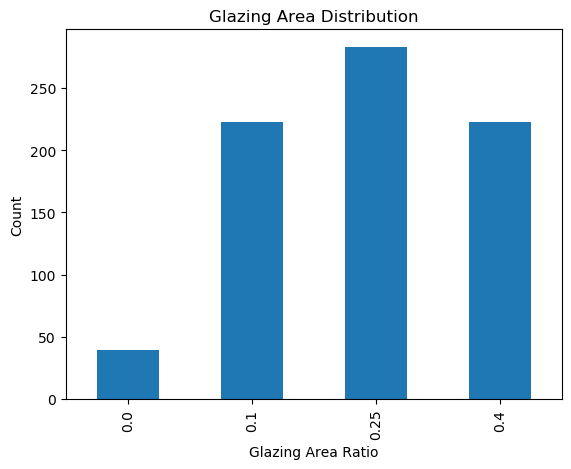

In [40]:
import matplotlib.pyplot as plt

glazing_counts.plot(kind='bar')
plt.title("Glazing Area Distribution")
plt.xlabel("Glazing Area Ratio")
plt.ylabel("Count")
plt.show()

In [41]:
# 0.0 (no glazing) → very few buildings (~40)
# 0.1 - 0.4 (heavily glazed) → many buildings (~220+)

# Heating Load 
8. What is the typical heating demand of a building in this dataset? 
9. Are there buildings that need dramatically more heating than the average — and how many?

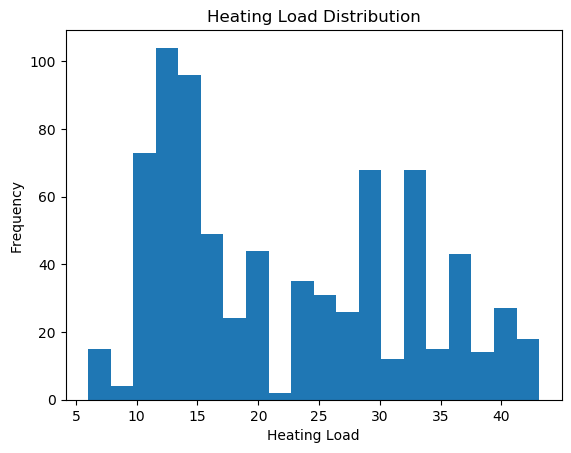

In [42]:
import matplotlib.pyplot as plt

plt.hist(dataset['Heating_Load_kWh'], bins=20)
plt.title("Heating Load Distribution")
plt.xlabel("Heating Load")
plt.ylabel("Frequency")
plt.show()

In [43]:
print("Mean:", dataset['Heating_Load_kWh'].mean())
print("Median:", dataset['Heating_Load_kWh'].median())

Mean: 22.323940104166667
Median: 19.27


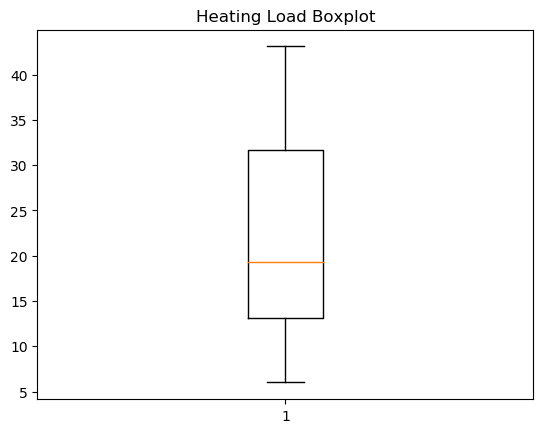

In [44]:
plt.boxplot(dataset['Heating_Load_kWh'])
plt.title("Heating Load Boxplot")
plt.show()

In [45]:
#The typical heating load is around 19–20, based on the median value.
#There are no significant outliers, indicating that no buildings require dramatically higher heating than others.

# Cooling Load
10. Same as above — what does a "normal" cooling demand look like here?
11. Do heating and cooling demands follow the same pattern, or does one vary more wildly than the other?

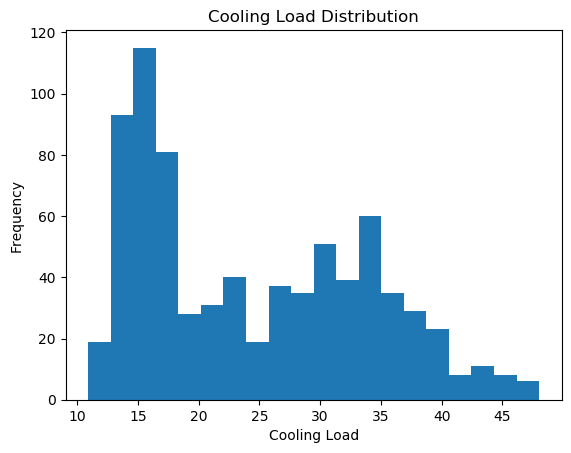

In [46]:
import matplotlib.pyplot as plt

plt.hist(dataset['Cooling_Load_kWh'], bins=20)
plt.title("Cooling Load Distribution")
plt.xlabel("Cooling Load")
plt.ylabel("Frequency")
plt.show()

In [47]:
print("Mean:", dataset['Cooling_Load_kWh'].mean())
print("Median:", dataset['Cooling_Load_kWh'].median())

Mean: 24.485039062500004
Median: 22.17


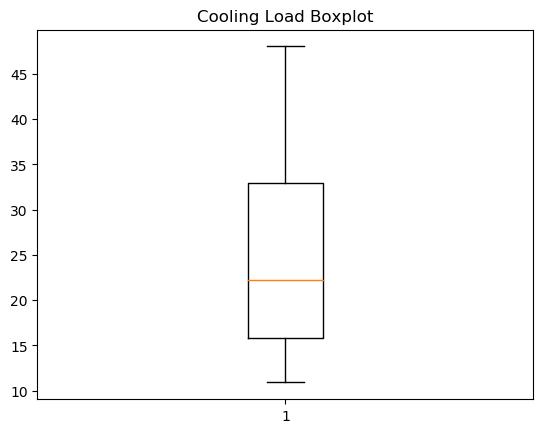

In [48]:
plt.boxplot(dataset['Cooling_Load_kWh'])
plt.title("Cooling Load Boxplot")
plt.show()

In [49]:
#The typical cooling load is around 22–24, based on the median value.
#There are no significant outliers, indicating that no buildings require dramatically higher cooling than others.

# Bivariate Analysis

# Shape → Energy 

Do more compact buildings actually use less heating energy, or is that assumption wrong? 
Does a larger surface area always mean higher cooling costs, or does it depend on other factors?

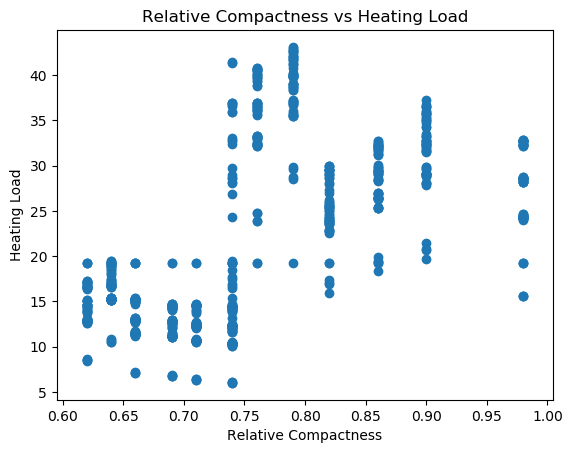

In [50]:
import matplotlib.pyplot as plt

plt.scatter(dataset['Relative_Compactness'], dataset['Heating_Load_kWh'])
plt.title("Relative Compactness vs Heating Load")
plt.xlabel("Relative Compactness")
plt.ylabel("Heating Load")
plt.show()

In [51]:
# Correlation value
print(dataset[['Relative_Compactness', 'Heating_Load_kWh']].corr())

                      Relative_Compactness  Heating_Load_kWh
Relative_Compactness              1.000000          0.595999
Heating_Load_kWh                  0.595999          1.000000


In [52]:
# Moderate positive relationship

# As Relative Compactness increases - Heating Load also tends to increase

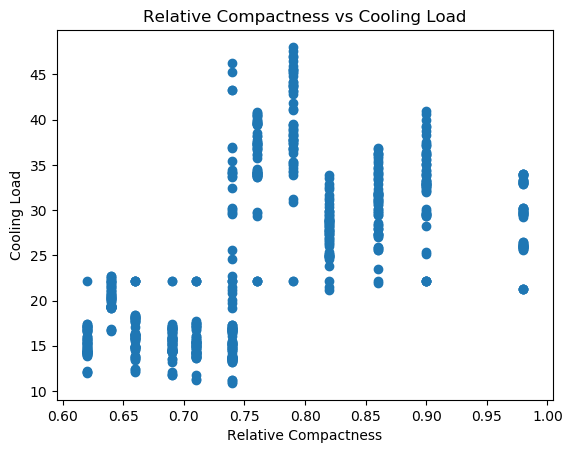

In [53]:
import matplotlib.pyplot as plt

plt.scatter(dataset['Relative_Compactness'], dataset['Cooling_Load_kWh'])
plt.title("Relative Compactness vs Cooling Load")
plt.xlabel("Relative Compactness")
plt.ylabel("Cooling Load")
plt.show()

In [54]:
# Correlation value
print(dataset[['Relative_Compactness', 'Cooling_Load_kWh']].corr())

                      Relative_Compactness  Cooling_Load_kWh
Relative_Compactness              1.000000          0.607909
Cooling_Load_kWh                  0.607909          1.000000


In [55]:
# Moderate positive relationship

# As Relative Compactness increases - Cooling Load also tends to increase

In [56]:
# Practically this is not the case hence there must be other factors which are more significant

# Glass → Energy 

Do buildings with more windows and glass always overheat and need more cooling?

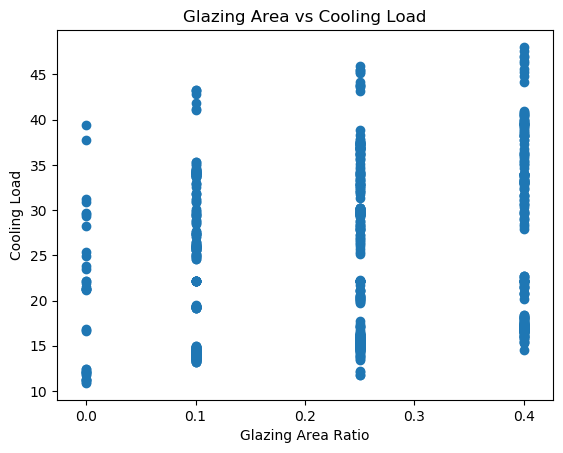

In [57]:
import matplotlib.pyplot as plt

plt.scatter(dataset['Glazing_Area_ratio'], dataset['Cooling_Load_kWh'])
plt.title("Glazing Area vs Cooling Load")
plt.xlabel("Glazing Area Ratio")
plt.ylabel("Cooling Load")
plt.show()

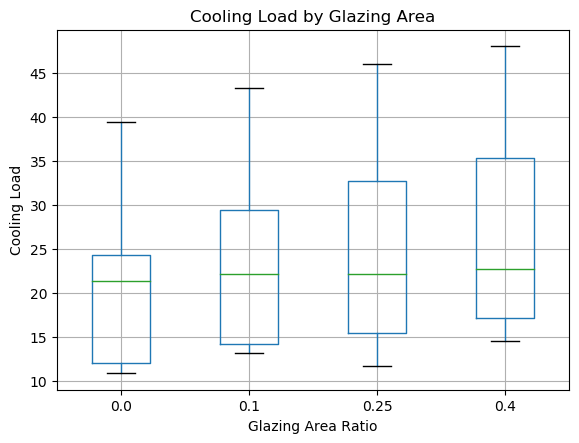

In [58]:
import matplotlib.pyplot as plt

dataset.boxplot(column='Cooling_Load_kWh', by='Glazing_Area_ratio')
plt.title("Cooling Load by Glazing Area")
plt.suptitle("")
plt.xlabel("Glazing Area Ratio")
plt.ylabel("Cooling Load")
plt.show()

In [59]:
# Buildings with higher glazing area generally require more cooling,
#indicating that increased window area contributes to heat gain ie more cooling load.

# Which orientation — North, East, South, West — has the lowest average heating demand?

In [60]:
# Average heating load for each orientation
orientation_heating = dataset.groupby('Orientation')['Heating_Load_kWh'].mean()

print(orientation_heating)

Orientation
East     22.388820
North    22.409774
South    22.064615
West     22.408034
Name: Heating_Load_kWh, dtype: float64


In [61]:
#equally distributed across 4

# Does glazing distribution type matter as much as glazing amount, or is how much glass you have more important than where you put it?

In [62]:
dataset[['Glazing_Area_ratio', 'Cooling_Load_kWh']].corr()

,Glazing_Area_ratio,Cooling_Load_kWh
Glazing_Area_ratio,1.000000,0.206142
Cooling_Load_kWh,0.206142,1.000000


In [63]:
# Average cooling by glazing distribution
dataset.groupby('Glazing_Distribution')['Cooling_Load_kWh'].mean()

Glazing_Distribution
East_Heavy     23.973750
North_Heavy    24.936563
South_Heavy    24.977519
Uniform        24.755312
West_Heavy     24.247710
Name: Cooling_Load_kWh, dtype: float64

In [64]:
#both effects are relatively weak when considered individually.

# Which combination of building type and orientation produces the highest heating load?

In [65]:
# Average heating load by Building Type and Orientation
combo_heating = dataset.groupby(['Building_Type', 'Orientation'])['Heating_Load_kWh'].mean()

print(combo_heating)

Building_Type  Orientation
High_Rise      East           30.745000
               North          31.312022
               South          30.967011
               West           31.004831
Low_Rise       East           13.842727
               North          13.406364
               South          13.646043
               West           13.663017
Name: Heating_Load_kWh, dtype: float64


In [66]:
#Highrise with all orientations provide more heating load than low rise

## Import Libraries

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split 
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt


## StandardScaler

In [68]:
def selectkbest(indep_X,dep_Y,n):
        test = SelectKBest(score_func=f_regression, k=n)
        fit1= test.fit(indep_X,dep_Y)
        selectk_features = fit1.transform(indep_X)
        return selectk_features

## r2 prediction model

In [69]:
def r2_prediction(regressor,X_test,y_test):
     y_pred = regressor.predict(X_test)
     from sklearn.metrics import r2_score
     r2=r2_score(y_test,y_pred)
     return r2

In [70]:
def Linear(X_train, y_train, X_test, y_test):       
        # Fitting Logistic Regression to the Training set
        from sklearn.linear_model import LinearRegression
        regressor = LinearRegression()
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2 
def svm_linear(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVR
    model = SVR(kernel='linear')
    model.fit(X_train, y_train)
    return r2_prediction(model, X_test, y_test)
def svm_NL(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVR
    model = SVR(kernel='rbf')
    model.fit(X_train, y_train)
    return r2_prediction(model, X_test, y_test)
def Decision(X_train, y_train, X_test, y_test):
        
        # Fitting Decision Tree to the Training set
        from sklearn.tree import DecisionTreeRegressor
        regressor = DecisionTreeRegressor(random_state = 0)
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2 
def random(X_train, y_train, X_test, y_test):      
    
        # Fitting Random Forest to the Training set
        from sklearn.ensemble import RandomForestRegressor
        regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2 

## Comparison table of accuracies of different models.

In [71]:
def selectk_regression(acclin,accsvml,accsvmnl,accdes,accrf): 
    
    dataframe=pd.DataFrame(index=['ChiSquare'],columns=['Linear','SVMl','SVMnl','Decision','Random'
                                                                                     ])

    for number,idex in enumerate(dataframe.index):
        
        dataframe['Linear'][idex]=acclin[number]       
        dataframe['SVMl'][idex]=accsvml[number]
        dataframe['SVMnl'][idex]=accsvmnl[number]
        dataframe['Decision'][idex]=accdes[number]
        dataframe['Random'][idex]=accrf[number]
    return dataframe

In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


dataset['Building_Type'] = dataset['Building_Type'].map({
    'Low_Rise'  : 0,
    'Mid_Rise'  : 1,
    'High_Rise' : 2
})


dataset['Orientation']          = le.fit_transform(dataset['Orientation'])
dataset['Glazing_Distribution'] = le.fit_transform(dataset['Glazing_Distribution'])


indep_X = dataset.drop(columns=['Building_ID', 'Heating_Load_kWh', 'Cooling_Load_kWh'])
dep_Y   = dataset['Heating_Load_kWh']


print(indep_X.dtypes)          
print("\nShape:", indep_X.shape)  

Relative_Compactness    float64
Building_Type             int64
Surface_Area_m2         float64
Wall_Area_m2            float64
Roof_Area_m2            float64
Overall_Height_m        float64
Orientation               int32
Glazing_Area_ratio      float64
Glazing_Distribution      int32
dtype: object

Shape: (768, 9)


## 

In [73]:

indep_X = dataset.drop(columns=['Building_ID', 'Heating_Load_kWh', 'Cooling_Load_kWh'])

dep_Y = dataset['Heating_Load_kWh']

print("indep_X shape:", indep_X.shape)   
print("dep_Y shape:", dep_Y.shape)       
print("\nColumns in indep_X:")
print(indep_X.columns.tolist())          

indep_X shape: (768, 9)
dep_Y shape: (768,)

Columns in indep_X:
['Relative_Compactness', 'Building_Type', 'Surface_Area_m2', 'Wall_Area_m2', 'Roof_Area_m2', 'Overall_Height_m', 'Orientation', 'Glazing_Area_ratio', 'Glazing_Distribution']


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_scalar(indep_X, dep_Y):
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        indep_X, dep_Y, test_size=0.2, random_state=0
    )
    # Scale the features
    sc       = StandardScaler()
    X_train  = sc.fit_transform(X_train)   
    X_test   = sc.transform(X_test)        
    
    return X_train, X_test, y_train, y_test

In [75]:
kbest = selectkbest(indep_X, dep_Y, 7)

X_train, X_test, y_train, y_test = split_scalar(kbest, dep_Y)

acclin = []
accsvml = []
accsvmnl = []
accdes = []
accrf = []

acclin.append(Linear(X_train, y_train, X_test, y_test))
accsvml.append(svm_linear(X_train, y_train, X_test, y_test))
accsvmnl.append(svm_NL(X_train, y_train, X_test, y_test))
accdes.append(Decision(X_train, y_train, X_test, y_test))
accrf.append(random(X_train, y_train, X_test, y_test))

C:\Users\FawadSaleem\Anaconda3\envs\aiml\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
C:\Users\FawadSaleem\Anaconda3\envs\aiml\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):


In [76]:
from sklearn.feature_selection import SelectKBest, f_regression

bestfeatures = SelectKBest(score_func=f_regression, k=7)
fit = bestfeatures.fit(indep_X, dep_Y)

In [77]:
selected_columns = indep_X.columns[bestfeatures.get_support()]

print(selected_columns)

Index(['Relative_Compactness', 'Building_Type', 'Surface_Area_m2',
       'Wall_Area_m2', 'Roof_Area_m2', 'Overall_Height_m',
       'Glazing_Area_ratio'],
      dtype='object')


In [78]:
table=selectk_regression(acclin,accsvml,accsvmnl,accdes,accrf)
table

,Linear,SVMl,SVMnl,Decision,Random
ChiSquare,0.870983,0.867299,0.899754,0.965406,0.963759


In [79]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor()
final_model.fit(kbest, dep_Y)


C:\Users\FawadSaleem\Anaconda3\envs\aiml\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
C:\Users\FawadSaleem\Anaconda3\envs\aiml\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):


RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
                      max_features='auto', max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, n_estimators=10,
                      n_jobs=None, oob_score=False, random_state=None,
                      verbose=0, warm_start=False)

In [80]:
import pickle

file_name = "finalised_model_SelectKReg.sav"

pickle.dump(final_model, open(file_name, 'wb')) 

loaded_model = pickle.load(open("finalised_model_SelectKReg.sav", 'rb'))

result = loaded_model.predict([[0.98, 1, 514.5, 294, 110.25, 7, 0.25]])

print("Predicted Heating Load:", result)

Predicted Heating Load: [12.899]


C:\Users\FawadSaleem\Anaconda3\envs\aiml\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
